In [1]:
import os
import sys
sys.path.insert(0, os.getcwd())

import torch
import random
from omegaconf import DictConfig
from pytorch_lightning import Trainer

import numpy as np

from tsl import logger
from tsl.data import ImputationDataset, SpatioTemporalDataModule
from tsl.data.preprocessing import StandardScaler
from tsl.engines import Imputer
from tsl.metrics import numpy as numpy_metrics
from tsl.transforms import MaskInput
from tsl.utils.casting import torch_to_numpy

from omegaconf import OmegaConf
from geode_filler import GeodeFiller
from geode import Geode
from KITS_filler import GCNCycVirtualFiller
from geodeCross_filler import GeodeCrossFiller

import matplotlib.pyplot as plt
from run_exp import get_model_class, get_dataset
from utils import add_missing_sensors, LargeST, AirCross, add_missing_sensors_cross, CrossSpatioTemporalDataset, StandardScalerSplit

In [2]:
mask_s = None

# mask_s = [1, 8, 9, 21, 35]
# mask_s = [0, 5, 18, 19, 31]
dataset = ['aqi', 'aqism', 'metrla', 'pem07', 'pem04', 'nrel-al', 'nrel-md', 'sd', 'electricity']
np.random.seed(15900376)

# dataset, masked_sensors = get_dataset('air_invercargill2', p_noise=0.25, masked_s=mask_s, mode = 'road', connectivity={'method': 'distance', 'threshold': 0.1, 'include_self': False})
dataset, masked_sensors = get_dataset('sd', 
                                      p_noise=0.25, 
                                      masked_s=mask_s,
                                      connectivity={'method': 'precomputed', 'threshold': 0.1, 'include_self': False})#, spatial_shift=True, node_features='c_centrality')
# covariates = {'u': dataset.datetime_encoded('day').values}
adj = dataset.get_connectivity(method='precomputed', threshold=0.1, include_self=False, layout='dense')

import networkx as nx
from utils import closest_distances_unweighted
import math

unmask = [i for i in range(adj.shape[0]) if i not in masked_sensors]
print(masked_sensors)
masked = list(range(adj.shape[0]))

numpy_graph = nx.from_numpy_array(adj)
closeness = nx.closeness_centrality(numpy_graph)
init_hops = closest_distances_unweighted(numpy_graph, masked, unmask)
print(max(x for x in init_hops.values() if not math.isinf(x)))

[1, 6, 12, 13, 19, 21, 29, 36, 37, 39, 49, 52, 53, 54, 55, 56, 58, 59, 62, 72, 74, 75, 77, 83, 84, 89, 95, 96, 100, 103, 105, 108, 109, 117, 119, 120, 122, 126, 133, 138, 139, 145, 149, 150, 153, 160, 161, 163, 165, 169, 170, 171, 196, 204, 206, 214, 220, 221, 226, 238, 239, 244, 247, 251, 252, 257, 261, 262, 263, 266, 269, 270, 278, 282, 285, 291, 297, 300, 301, 302, 306, 308, 309, 311, 316, 320, 324, 326, 327, 328, 332, 337, 344, 346, 349, 350, 362, 363, 365, 366, 381, 385, 387, 391, 398, 399, 407, 417, 418, 422, 427, 428, 436, 438, 448, 453, 454, 456, 458, 462, 464, 467, 468, 469, 486, 492, 493, 497, 499, 502, 503, 506, 514, 515, 522, 529, 530, 532, 538, 542, 552, 554, 559, 561, 562, 576, 577, 578, 580, 583, 584, 586, 593, 598, 600, 601, 603, 604, 605, 607, 608, 612, 613, 615, 624, 627, 629, 630, 635, 636, 642, 649, 656, 660, 666, 672, 674, 684, 691, 693, 695, 700, 711, 713, 714]
1


In [2]:
def get_dataset(dataset_name: str, p_fault=0., p_noise=0., masked_s=None, connectivity=None, 
                spatial_shift=False, order=0, node_features='CC', t_range = ['2022-04-01', '2022-12-01'], 
                agg_func = 'mean', test_month=[5], location='Auckland', include_traffic=False):
    if dataset_name == 'aircross':
        return add_missing_sensors_cross(AirCross(root='../data', include_traffic=include_traffic),
                                        p_fault=p_fault,
                                        p_noise=p_noise,
                                        min_seq=12,
                                        max_seq=12 * 4,
                                        masked_sensors=masked_s,
                                        connect=connectivity,
                                        spatial_shift=spatial_shift,
                                        order=order,
                                        node_features=node_features)

    raise ValueError(f"Dataset {dataset_name} not available in this setting.")

In [ ]:
import os

def load_model_and_infer(og_path: str, index, dev, node_features=None):
    torch.set_float32_matmul_precision('high')
    
    result = []
    for root, dirs, files in os.walk(og_path):
        for name in files:
            if 'ckpt' in name:
                result.append(os.path.join(root, name))
    
    print(result)
    assert len(result)
    checkpoint_path = result[index]
    
    # Load configuration
    cfg = OmegaConf.load(os.path.join(og_path, 'config.yaml'))
    print(cfg.seed)
    torch.manual_seed(cfg.seed)
    np.random.seed(cfg.seed)
    random.seed(cfg.seed)
    
    # Load dataset
    dataset, masked_sensors = get_dataset(cfg.dataset.name,
                            p_fault=cfg.dataset.get('p_fault'),
                            p_noise=cfg.dataset.get('p_noise'),
                            masked_s=cfg.dataset.get('masked_sensors'),
                            connectivity=cfg.dataset.get('connectivity'),
                            spatial_shift=cfg.dataset.get('spatial_shift'),
                            order=cfg.dataset.get('order'),
                            node_features=cfg.dataset.get('node_features'),
                            t_range=cfg.dataset.get('t_range'),
                            agg_func=cfg.dataset.get('agg_func'),
                            test_month=cfg.dataset.get('test_month'),
                            location=cfg.dataset.get('location'),
                            include_traffic=cfg.dataset.get('include_traffic', False))
    print(f'Masked sensors: {masked_sensors}')
    # covariates = {'u': dataset.datetime_encoded('day').values}

    # get adjacency matrix
    adj = dataset.get_connectivity(**cfg.dataset.connectivity, layout='dense')

    # instantiate dataset
    if cfg.dataset.get('include_traffic', False):
        covariates = {'modality': dataset.modality}
        torch_dataset = CrossSpatioTemporalDataset(target=dataset.dataframe(),
                                                    mask=dataset.training_mask,
                                                    eval_mask=dataset.eval_mask,
                                                    covariates=covariates,
                                                    transform=MaskInput(),
                                                    connectivity=adj,
                                                    window=cfg.window,
                                                    stride=cfg.stride)
    else:
        torch_dataset = ImputationDataset(target=dataset.dataframe(),
                                        mask=dataset.training_mask,
                                        eval_mask=dataset.eval_mask,
                                        transform=MaskInput(),
                                        connectivity=adj,
                                        window=cfg.window,
                                        stride=cfg.stride)

    if cfg.scaler == 'StandardScaler':
        scalers = {'target': StandardScaler(axis=(0, 1))}
    elif cfg.scaler == 'StandardScalerSplit':
        scalers = {'target': StandardScalerSplit(axis=(0, 1), split=dataset.air_max_nodes)}
    else:
        raise ValueError(f"Scaler {cfg.scaler} not available in this setting.")
    val_len = cfg.dataset.splitting.get('val_len')
    test_len = cfg.dataset.splitting.get('test_len')
    dm = SpatioTemporalDataModule(
        dataset=torch_dataset,
        scalers=scalers,
        splitter=dataset.get_splitter(val_len=val_len, test_len=test_len),
        batch_size=cfg.batch_size,
        workers=cfg.workers)
    
    dm.setup(stage='test')
    
    # Load model
    model_cls = get_model_class(cfg.model.name)
    
    if cfg.model.name == 'kits':
        model_kwargs = dict(adj=adj, d_in=dm.n_channels, n_nodes=dm.n_nodes, args=cfg.model)
    elif cfg.model.name =='geode' or cfg.model.name == 'geodeNAall' or cfg.model.name == 'geodeCross':
        model_kwargs = dict(adj=adj, input_size=dm.n_channels, output_size=dm.n_channels, horizon=cfg.window)
        
    model_cls.filter_model_args_(model_kwargs)
    model_kwargs.update(cfg.model.hparams)

    trainer = Trainer(
        max_epochs=cfg.epochs,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=cfg.device,
        detect_anomaly=False)
    print(model_cls)

    if cfg.model.name == 'kits':
        imputer = GCNCycVirtualFiller.load_from_checkpoint(checkpoint_path, 
                                                           model_class=model_cls, 
                                                           model_kwargs=model_kwargs,
                                                           gradient_clip_val=cfg.grad_clip_val,
                                                           gradient_clip_algorithm=cfg.grad_clip_alg,
                                                           known_nodes = [i for i in range(adj.shape[0]) if i not in masked_sensors],
                                                           **cfg.model.technique)
    elif cfg.model.name == 'geode' or cfg.model.name == 'geodeNAall':
        imputer = GeodeFiller.load_from_checkpoint(checkpoint_path,
                                                model_class=model_cls,
                                                model_kwargs=model_kwargs,
                                                gradient_clip_val=cfg.grad_clip_val,
                                                gradient_clip_algorithm=cfg.grad_clip_alg,
                                                known_set = [i for i in range(adj.shape[0]) if i not in masked_sensors],
                                                **cfg.model.regs)
    elif cfg.model.name =='geodeCross':
        imputer = GeodeCrossFiller.load_from_checkpoint(checkpoint_path,
                                        model_class=model_cls,
                                        model_kwargs=model_kwargs,
                                        gradient_clip_val=cfg.grad_clip_val,
                                        gradient_clip_algorithm=cfg.grad_clip_alg,
                                        known_set = [i for i in range(dataset.air_max_nodes) if i not in masked_sensors],
                                        **cfg.model.regs)
    imputer.eval()

    # trainer.test(imputer, datamodule=dm)
    
    # # Run inference
    # trainer = torch.utils.data.DataLoader(dm.test_dataloader(), batch_size=cfg.batch_size)
    output = trainer.predict(imputer, dataloaders=dm.test_dataloader())
    output = imputer.collate_prediction_outputs(output)
    output = torch_to_numpy(output)
    
    y_hat, y_true, mask = (output['y_hat'], output['y'],
                           output.get('eval_mask', None))

    res = dict(test_mae=numpy_metrics.mae(y_hat, y_true, mask),
               test_mre=numpy_metrics.mre(y_hat, y_true, mask),
               test_mape=numpy_metrics.mape(y_hat, y_true, mask),
               test_rmse=numpy_metrics.rmse(y_hat, y_true, mask))

    # return output[-2], output[-1]
    
    return y_hat, y_true, mask, res, dm, dataset, model_cls, adj, [i for i in range(adj.shape[0]) if i not in masked_sensors]


In [11]:
paths = [['../logs/aircross/2025-09-16/12-48-41', 0] , ['../logs/aircross/2025-09-17/13-18-49', 1]]

deets = []
for path in paths:
    res = load_model_and_infer(path[0], path[1], 3)
    deets.append(res)
    print(res[3])

['../logs/aircross/2025-09-16/12-48-41/epoch=61-step=4898.ckpt', '../logs/aircross/2025-09-16/12-48-41/epoch=111-last.ckpt']
15900376
Masked sensors: [1, 6, 12, 13]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


<class 'geodeCross.GeodeCross'>


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4]


Predicting DataLoader 0: 100%|██████████| 9/9 [00:00<00:00, 14.42it/s]
{'test_mae': 0.0026474164, 'test_mre': 0.4052110774127154, 'test_mape': 0.48740345, 'test_rmse': 0.004201804}
['../logs/aircross/2025-09-17/13-18-49/epoch=67-step=5372.ckpt', '../logs/aircross/2025-09-17/13-18-49/epoch=102-last.ckpt']
15900376
Masked sensors: [1, 6, 12, 13]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


<class 'geodeCross.GeodeCross'>


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4]


Predicting DataLoader 0: 100%|██████████| 9/9 [00:01<00:00,  7.01it/s]
{'test_mae': 0.0031666714, 'test_mre': 0.48468775755609933, 'test_mape': 0.7894953, 'test_rmse': 0.004574952}


(572, 24, 15, 1)
(572, 24, 15, 1)


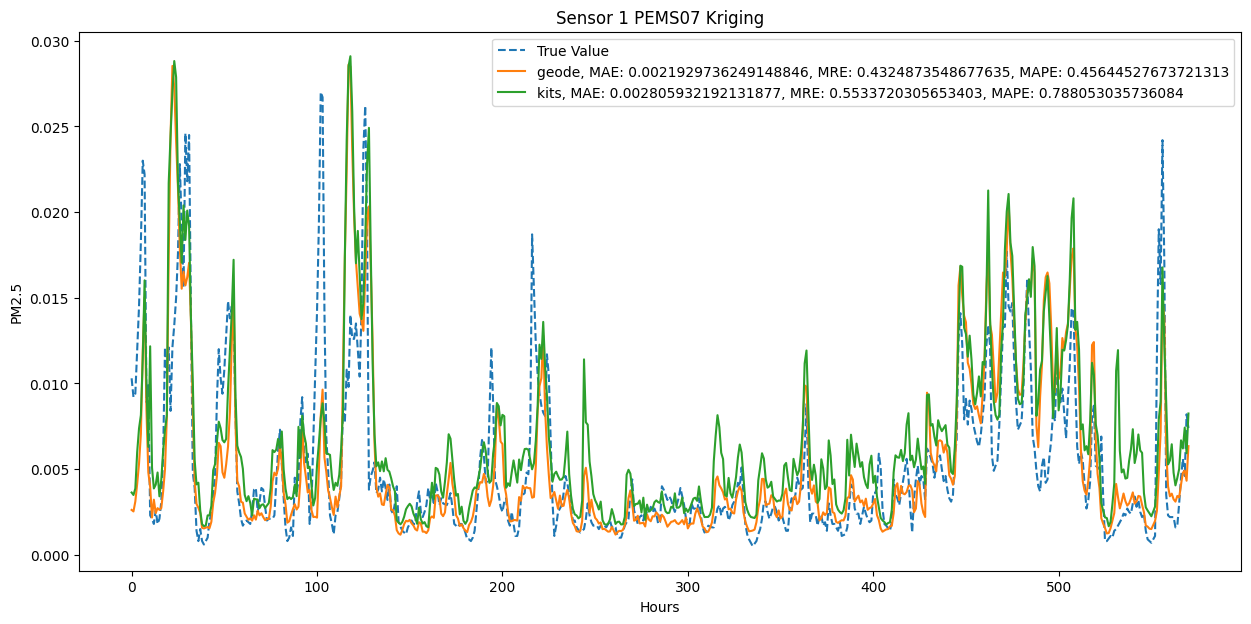

(572, 24, 15, 1)
(572, 24, 15, 1)


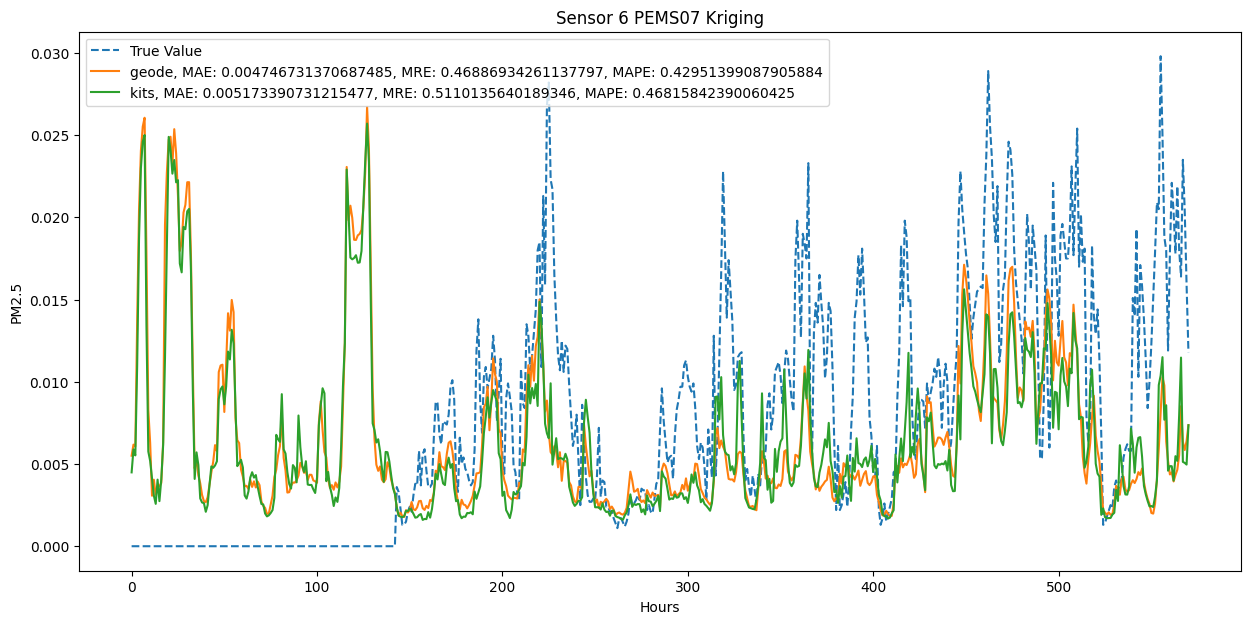

(572, 24, 15, 1)
(572, 24, 15, 1)


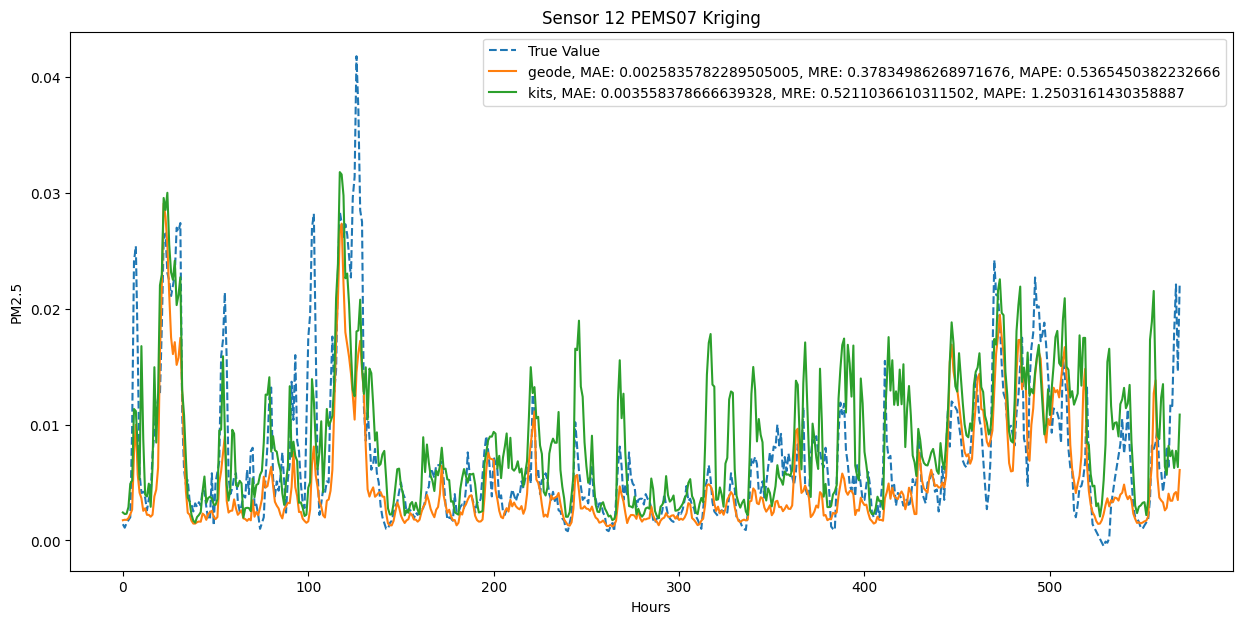

(572, 24, 15, 1)
(572, 24, 15, 1)


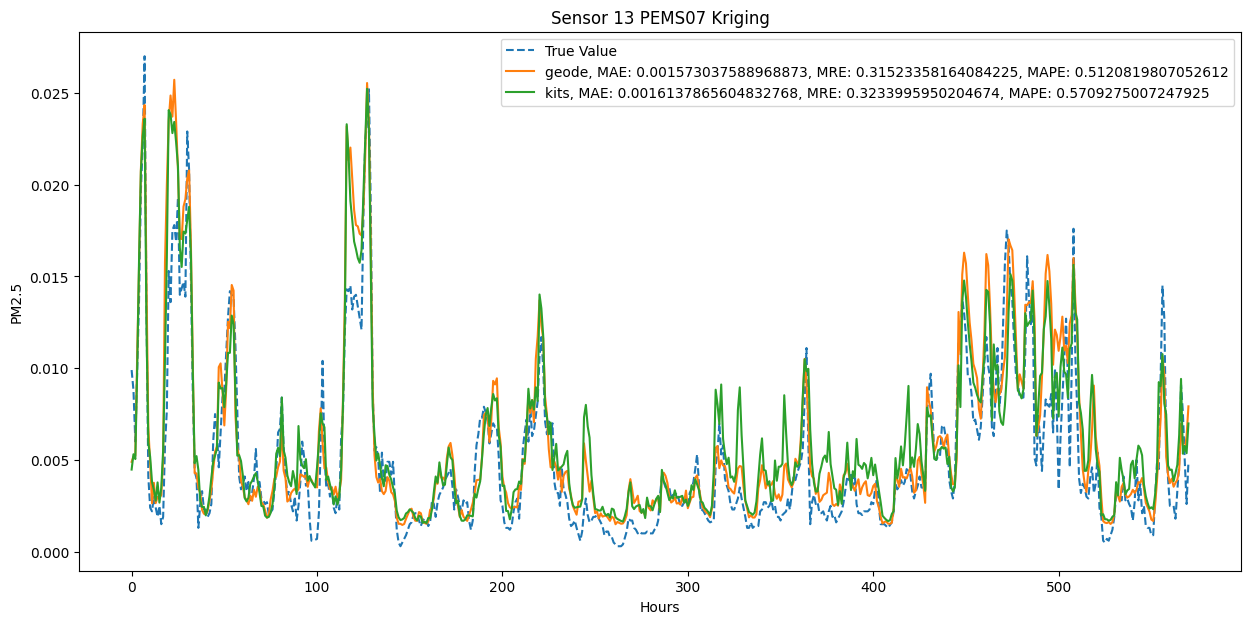

In [12]:
titles = ['geode', 'kits']
styles = ['-']
ranges = [0, -1]

sensors = [1, 6, 12, 13]
mae_deet = [0, 0]
mre_deet = [0, 0]
mape_deet = [0, 0]

for sensor in sensors:
    plt.figure(figsize=(15,7))
    y_true = deets[0][1]

    # y_true = np.where(deets[0][2] == 1, y_true, 400)

    plt.plot(y_true[ranges[0]:ranges[1], -1, sensor, :], '--', label='True Value')
    # plt.plot(deets[1][0][ranges[0]:ranges[1], 0, 33, :], '--', label='KITS')
    for ind, deet in enumerate(deets):
        # deet = deets[0]
        y_hat = deet[0]
        print(y_hat.shape)
        test_mae=numpy_metrics.mae(y_hat[ranges[0]:ranges[1], :, sensor, :], 
                                    y_true[ranges[0]:ranges[1], :, sensor, :], deets[0][2][ranges[0]:ranges[1], :, sensor])
        test_mre=numpy_metrics.mre(y_hat[ranges[0]:ranges[1], :, sensor, :], 
                                    y_true[ranges[0]:ranges[1], :, sensor, :], deets[0][2][ranges[0]:ranges[1], :, sensor])
        test_mape=numpy_metrics.mape(y_hat[ranges[0]:ranges[1], :, sensor, :], 
                                    y_true[ranges[0]:ranges[1], :, sensor, :], deets[0][2][ranges[0]:ranges[1], :, sensor])

    # if test_mre > 20:
        plt.plot(y_hat[ranges[0]:ranges[1], -1, sensor, :], label=f'{titles[ind]}, MAE: {test_mae}, MRE: {test_mre}, MAPE: {test_mape}')
        mae_deet[ind] += test_mae
        mre_deet[ind] += test_mre
        mape_deet[ind] += test_mape
        # plt.plot(deet[1][ranges[0]:ranges[1], 0, 4, :], label=f'True Value')

    # plt.ylim((0, 100))
    plt.xlabel('Hours')
    plt.ylabel('PM2.5')
    plt.legend()
    plt.title(f'Sensor {sensor} PEMS07 Kriging')
    plt.show()

In [45]:
import torch

b, s, n, d = 64, 24, 150, 32

xh_inv_3 = torch.rand((b,s,n,d))


n_cmd = int(n*0.8)
indx = torch.multinomial(torch.ones(n), n_cmd, replacement=False)
indx = set(indx.tolist())

finrecos = []
det_mask = torch.zeros_like(xh_inv_3).to(dtype=bool)
det_mask[:, :, :90] = 1
xh_inv_3[det_mask] = xh_inv_3[det_mask].detach()   

finrecos = []

In [48]:
len(indx)

120

In [ ]:
for i in range(1, self.k+1):
    prev_group = []
    cur_group = []

    for j in range(i):
        prev_group.extend(grouped[j])
    for j in range(i+1):
        cur_group.extend(grouped[j])

    prev_group = list(set(prev_group) | indx)
    cur_group = list(set(cur_group) | indx)

    emb_com_inv = vir_inv[:, :, prev_group]
    emb_tru_inv = vir_inv[:, :, cur_group]

In [46]:
prev_group = list(set([1,2,3,5,7,8,9]) & indx)

In [47]:
prev_group

[2, 3, 5, 7, 8, 9]

In [35]:
emb_com_inv = xh_inv_3[:, :, prev_group]
# emb_tru_inv = vir_inv[:, :, cur_group]

In [38]:
emb_com_inv.shape

torch.Size([64, 24, 5, 32])